In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# Data Collection

In [45]:
now = datetime.now()
ticker = 'META'
start = datetime(now.year - 10, now.month, now.day)
end = now
df = yf.download(ticker, start, end) # Obtains the stock price for every day from the past 10 years
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2016-09-23,126.746056,127.379991,126.092321,126.349849,28326300
2016-09-26,126.102242,126.944184,125.597085,126.161677,15064900
2016-09-27,127.469147,127.786103,126.221098,126.399391,15637100
2016-09-28,128.004028,128.241757,127.181900,127.984229,12047600
2016-09-29,126.874832,128.063445,126.339962,127.954488,14532200
...,...,...,...,...,...
2026-09-17,681.771973,682.661285,666.523996,681.901875,15928000
2026-09-18,665.225037,689.605821,660.278928,688.076998,27596400


In [46]:
print(df.empty) # make sure the data frame is not empty

False


# Moving Averages

In [47]:
df['MA100'] = df.Close.rolling(100).mean() # mean of the closing price of the stock from the last 100 days

In [48]:
df['MA200'] = df.Close.rolling(200).mean() # mean of the closing price of the stock from the last 100 days

In [49]:
df

Price,Close,High,Low,Open,Volume,MA100,MA200
Ticker,META,META,META,META,META,,
Date,,,,,,,
2016-09-23,126.746056,127.379991,126.092321,126.349849,28326300,NaN,NaN
2016-09-26,126.102242,126.944184,125.597085,126.161677,15064900,NaN,NaN
2016-09-27,127.469147,127.786103,126.221098,126.399391,15637100,NaN,NaN
2016-09-28,128.004028,128.241757,127.181900,127.984229,12047600,NaN,NaN
2016-09-29,126.874832,128.063445,126.339962,127.954488,14532200,NaN,NaN
...,...,...,...,...,...,...,...
2026-09-17,681.771973,682.661285,666.523996,681.901875,15928000,603.393259,622.922655
2026-09-18,665.225037,689.605821,660.278928,688.076998,27596400,603.270940,623.055263


In [50]:
df.isna().sum() # the first 99 days cannot have a 100 days moving average, and the first 199 days cannot have a 200 days moving average

Price   Ticker
Close   META        0
High    META        0
Low     META        0
Open    META        0
Volume  META        0
MA100              99
MA200             199
dtype: int64

Text(0, 0.5, 'Stock Price')

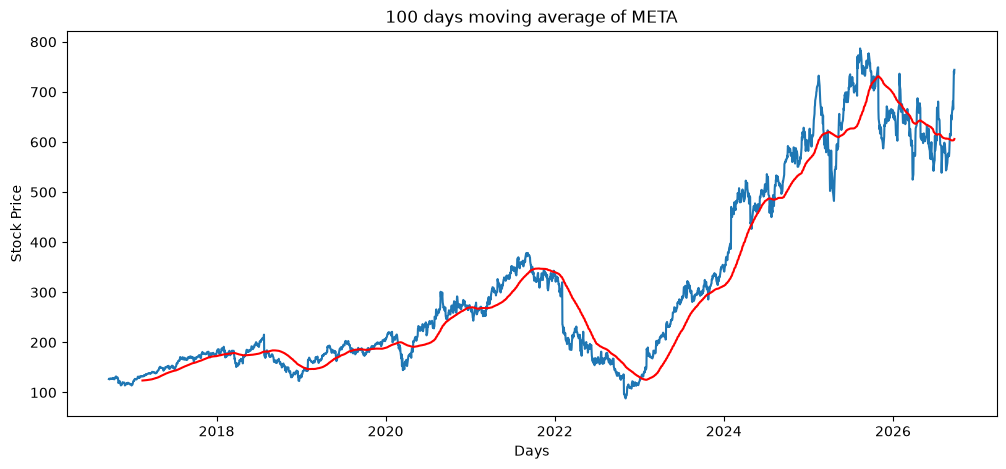

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA100'], 'r');
plt.title(f'100 days moving average of {ticker}')
plt.xlabel('Days')
plt.ylabel('Stock Price')

Text(0, 0.5, 'Stock Price')

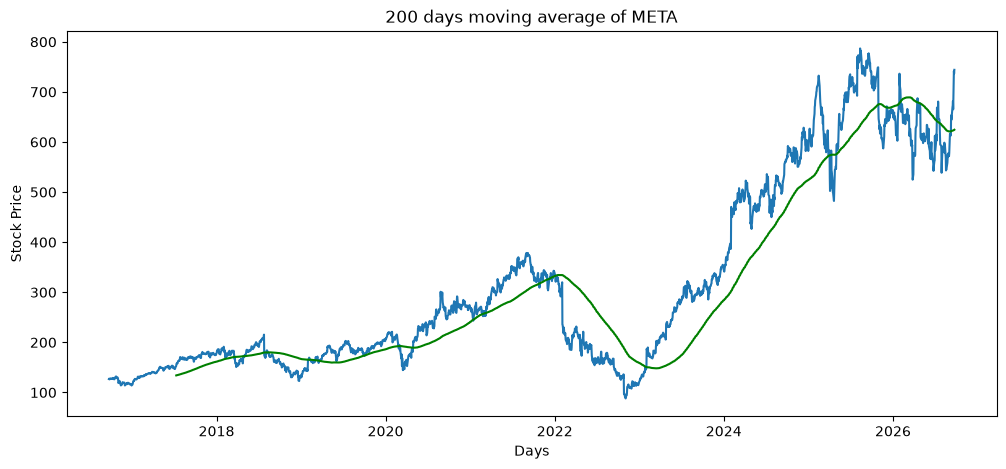

In [52]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA200'], 'g');
plt.title(f'200 days moving average of {ticker}')
plt.xlabel('Days')
plt.ylabel('Stock Price')

In [53]:
df

Price,Close,High,Low,Open,Volume,MA100,MA200
Ticker,META,META,META,META,META,,
Date,,,,,,,
2016-09-23,126.746056,127.379991,126.092321,126.349849,28326300,NaN,NaN
2016-09-26,126.102242,126.944184,125.597085,126.161677,15064900,NaN,NaN
2016-09-27,127.469147,127.786103,126.221098,126.399391,15637100,NaN,NaN
2016-09-28,128.004028,128.241757,127.181900,127.984229,12047600,NaN,NaN
2016-09-29,126.874832,128.063445,126.339962,127.954488,14532200,NaN,NaN
...,...,...,...,...,...,...,...
2026-09-17,681.771973,682.661285,666.523996,681.901875,15928000,603.393259,622.922655
2026-09-18,665.225037,689.605821,660.278928,688.076998,27596400,603.270940,623.055263


# Calculating % change

In [54]:
df['Percentage Change'] = df.Close.pct_change()
df[['Close', 'Percentage Change']]

Price,Close,Percentage Change
Ticker,META,
Date,,
2016-09-23,126.746056,NaN
2016-09-26,126.102242,-0.005080
2016-09-27,127.469147,0.010840
2016-09-28,128.004028,0.004196
2016-09-29,126.874832,-0.008822
...,...,...
2026-09-17,681.771973,0.013367
2026-09-18,665.225037,-0.024270


Text(0, 0.5, 'Percentage')

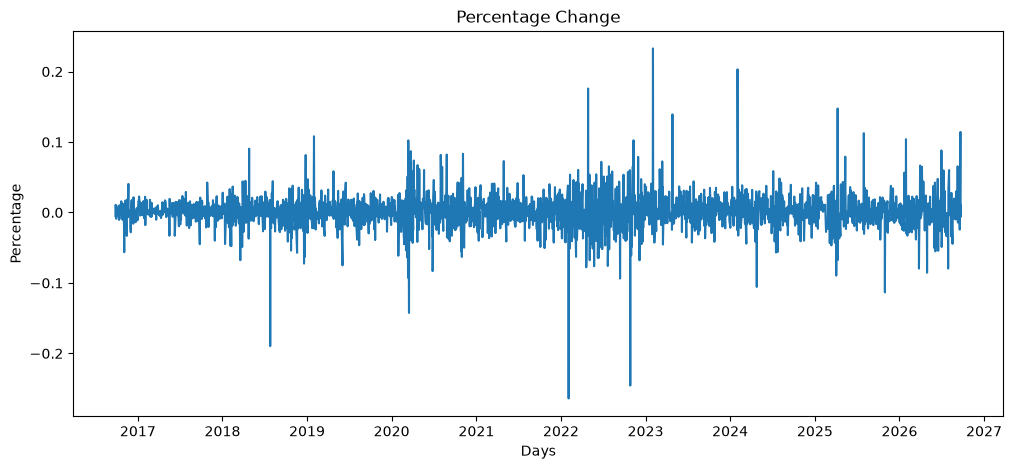

In [55]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Change']);
plt.title('Percentage Change')
plt.xlabel('Days')
plt.ylabel('Percentage')

# Data Preprocessing

## Splitting data into training and testing datasets

> **Note:** The data is split into two sections. The first 70% is used for training and the last 30% for testing. We train the model on the first 70%, then use it to predict the last 30%. We then compare those predictions to the actual data to gauge how accurate the model is.
>
> **The model does not predict future prices.**

In [56]:
split_index = int(len(df) * 0.7) # 70 percent (casting to int as value could be a float)
training_data = pd.DataFrame(df.Close[:split_index])
testing_data = pd.DataFrame(df.Close[split_index:])

In [57]:
training_data

Ticker,META
Date,
2016-09-23,126.746056
2016-09-26,126.102242
2016-09-27,127.469147
2016-09-28,128.004028
2016-09-29,126.874832
...,...
2023-09-14,308.762787
2023-09-15,297.461029
2023-09-18,299.679779


In [58]:
testing_data

Ticker,META
Date,
2023-09-21,292.924469
2023-09-22,296.242676
2023-09-25,297.976074
2023-09-26,296.123779
2023-09-27,294.915405
...,...
2026-09-17,681.771973
2026-09-18,665.225037
2026-09-21,741.250000


In [59]:
# Scale down the data to be between 0 and 1

In [60]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

In [61]:
training_data_array = scaler.fit_transform(training_data)
training_data_array

array([[0.13315367],
       [0.13093735],
       [0.1356429 ],
       ...,
       [0.72847545],
       [0.73706811],
       [0.718655  ]], shape=(1759, 1))

# Sequence Creation

In [62]:
training_data_array.shape

(1759, 1)

In [63]:
x_train = []
y_train = []

for i in range(100, training_data_array.shape[0]):
    x_train.append(training_data_array[i-100:i]) # we are using the previous 100 days of stock prices to predict the stock price
    # x_train is a 3D array as keras expects a 3D array
    y_train.append(training_data_array[i, 0])  # the actual stock prices from day 100 until end of training data (price is scaled)
    # y_train is a 1D array as appending the actual numerical value from the training data array

In [64]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [65]:
x_train.shape # we are only using the closing price for predictions so shape ends in 1

(1659, 100, 1)

In [66]:
y_train.shape

(1659,)

# Model Building

In [67]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [68]:
model = Sequential()
model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# Model Training

In [69]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0139
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0015
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0014
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0013
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 0.0012
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0012
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0011
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0011
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0010
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.0010
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 9.8875e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 9.6528e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 9.4167e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 9.1737e-04
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step

In [70]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [71]:
model.save('stock_prediction_model.keras')

# Preparing Test Data

In [72]:
testing_data

Ticker,META
Date,
2023-09-21,292.924469
2023-09-22,296.242676
2023-09-25,297.976074
2023-09-26,296.123779
2023-09-27,294.915405
...,...
2026-09-17,681.771973
2026-09-18,665.225037
2026-09-21,741.250000


In [73]:
past_100_days = training_data.tail(100) # we are using the previous 100 days to make the prediction

In [74]:
final_df = pd.concat([past_100_days, testing_data], ignore_index=True)
final_df

Ticker,META
0,238.040131
1,240.872986
2,236.970383
3,234.781342
4,231.304657
...,...
849,681.771973
850,665.225037
851,741.250000
852,736.599976


In [75]:
input_data = scaler.fit_transform(final_df) # scaling the data
input_data

array([[1.34270097e-02],
       [1.85199973e-02],
       [1.15037865e-02],
       [7.56826617e-03],
       [1.31778387e-03],
       [0.00000000e+00],
       [8.72523964e-04],
       [1.05058952e-03],
       [5.34251531e-04],
       [5.36007223e-03],
       [1.83417672e-03],
       [1.08271319e-02],
       [1.07558892e-02],
       [1.72912874e-02],
       [2.50554778e-02],
       [2.29007227e-02],
       [2.76731869e-02],
       [2.48596359e-02],
       [2.92581102e-02],
       [3.54552085e-02],
       [5.21053941e-02],
       [5.29600868e-02],
       [5.68778582e-02],
       [7.09281111e-02],
       [7.09281111e-02],
       [6.87555522e-02],
       [6.82747670e-02],
       [5.48834472e-02],
       [5.66285500e-02],
       [5.72874830e-02],
       [6.81501129e-02],
       [6.86309530e-02],
       [7.22459224e-02],
       [8.73467922e-02],
       [8.58687741e-02],
       [9.17988975e-02],
       [8.70086021e-02],
       [9.27782992e-02],
       [9.96342208e-02],
       [8.13634494e-02],


In [76]:
x_test = []
y_test = []

# same logic as the training
for i in range (100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)

# Making Predictions

In [77]:
y_predicted = model.predict(x_test) # predicted values

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step


In [78]:
# revert scaled prices to original prices
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

## Plotting Predictions

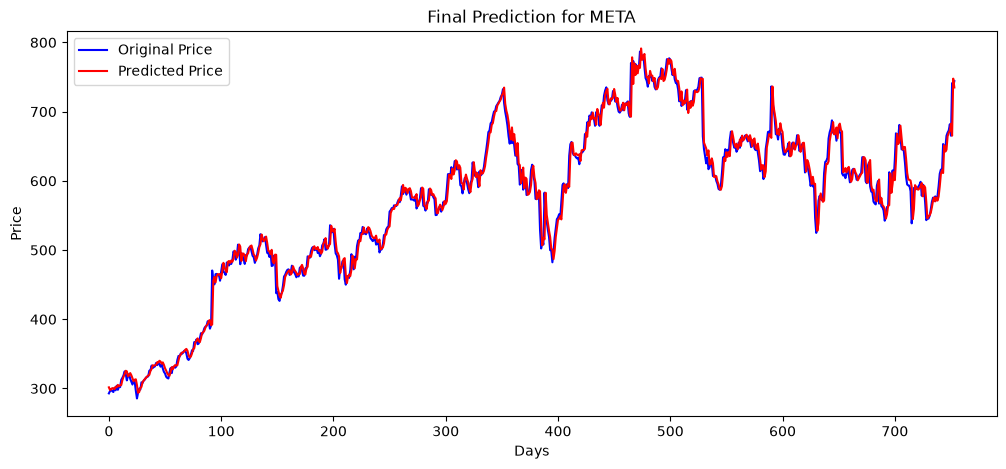

In [79]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.title(f'Final Prediction for {ticker}')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(400.0, 500.0)

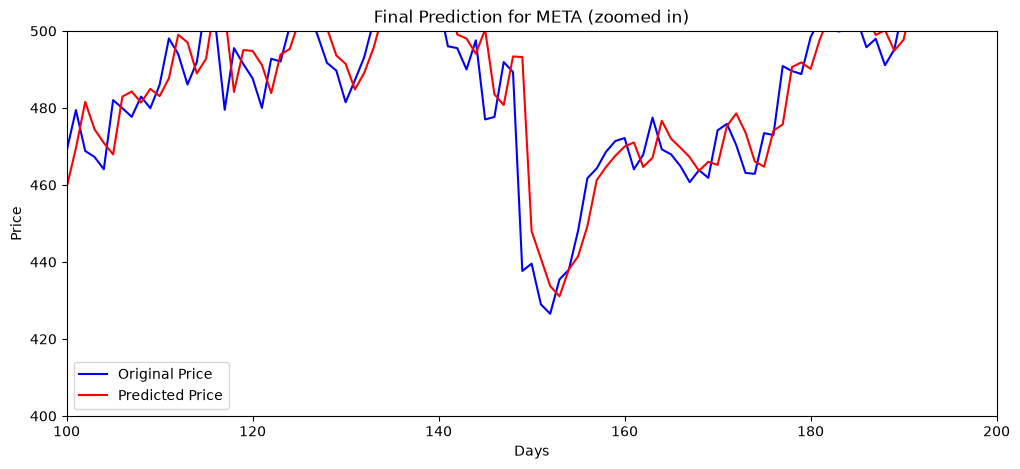

In [80]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.title(f'Final Prediction for {ticker} (zoomed in)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(100, 200)
plt.ylim(400, 500)

# Model Evaluation

In [85]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [86]:
# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_predicted)
mse

199.2103592384846

In [87]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
rmse

np.float64(14.114189995833435)

In [88]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
r2

0.9860148705986264

In [90]:
mape = mean_absolute_percentage_error(y_test, y_predicted) * 100
mape

1.6609872581066873